# Student Performance Prediction - Exploratory Data Analysis (EDA)

In this notebook, we will systematically explore the student performance dataset. We will perform rigorous data cleaning by analyzing missing values and outliers, followed by visualizing the relationships between different features and the `FinalGrade`. Finally, we will train a model to extract Feature Importances.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading

In [2]:
# Robust loading to prevent FileNotFoundError depending on where VS Code runs the notebook
file_path = '../data/student_performance.csv' if os.path.exists('../data/student_performance.csv') else 'data/student_performance.csv'
df = pd.read_csv(file_path)
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade
0,1,Student_1,Male,92,5,66,0,Medium,44
1,2,Student_2,Female,88,12,63,2,Medium,57
2,3,Student_3,Male,100,1,63,3,Medium,50
3,4,Student_4,Male,91,18,66,3,High,61
4,5,Student_5,Male,85,18,90,5,Low,69


## 2. Missing Values Analysis
Real-world data is often incomplete. We will check for null values and handle them appropriately before feeding the data to our model.

In [3]:
print("Missing values BEFORE handling:")
print(df.isnull().sum())

Missing values BEFORE handling:
StudentID                    0
Name                         0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
dtype: int64


In [4]:
# Handling missing values: 
# We will fill missing numerical values with the median, and categorical values with the mode.
numeric_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Using the updated pandas syntax to prevent FutureWarning
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
    
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values AFTER handling:")
print(df.isnull().sum())


Missing values AFTER handling:
StudentID                    0
Name                         0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
dtype: int64


## 3. Outlier Detection (Before Handling)
Outliers can heavily skew the performance of machine learning models like linear regression. We use Box Plots to visually identify extreme values in our numerical features.

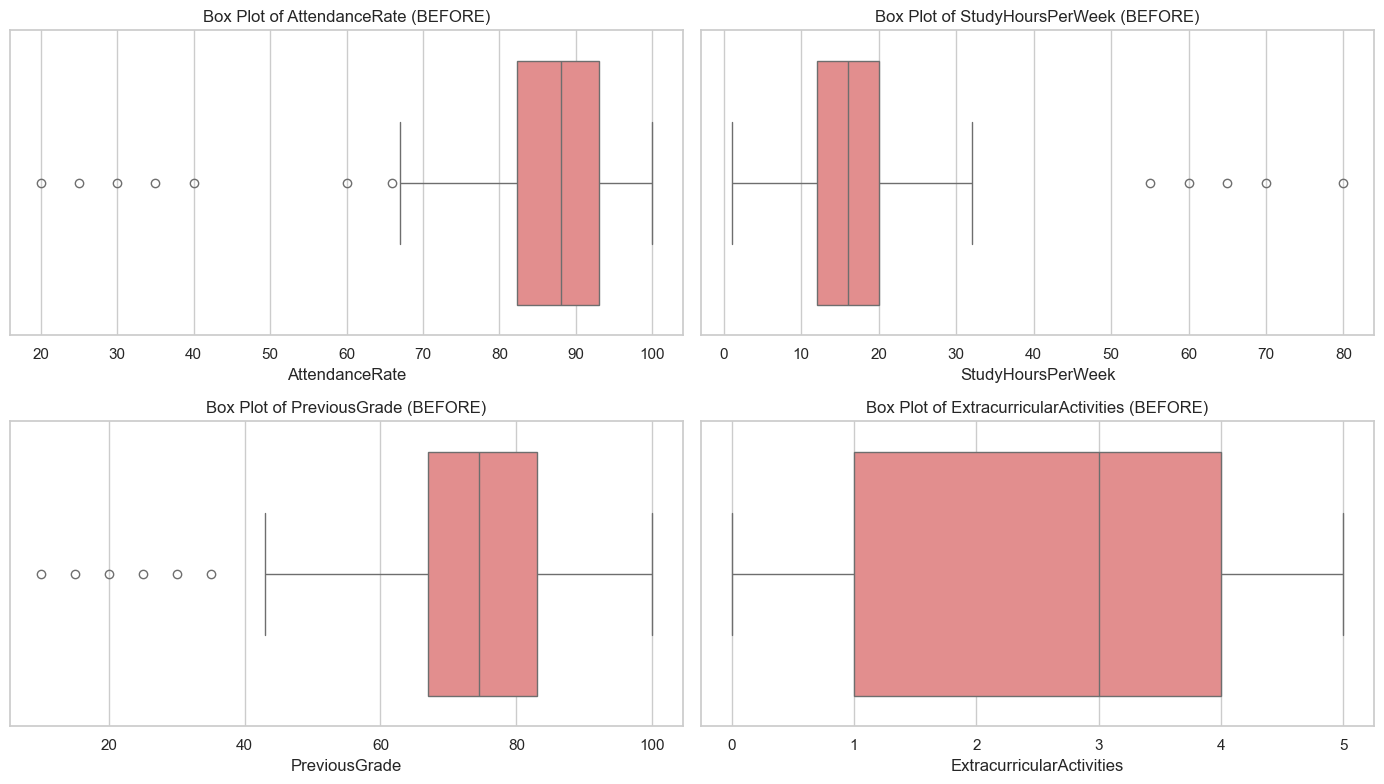

In [5]:
numerical_features = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities']

plt.figure(figsize=(14, 8))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Box Plot of {col} (BEFORE)')
plt.tight_layout()
plt.show()

In [6]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

print("Number of outliers BEFORE handling:")
for col in numerical_features:
    print(f"{col}: {count_outliers(df[col])}")

Number of outliers BEFORE handling:
AttendanceRate: 7
StudyHoursPerWeek: 5
PreviousGrade: 6
ExtracurricularActivities: 0


## 4. Outlier Handling (IQR Method)
We will cap extreme values using the Interquartile Range (IQR) method. This preserves the data points but brings them within a statistically acceptable threshold.

In [7]:
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return np.clip(series, lower_bound, upper_bound)

for col in numerical_features:
    df[col] = cap_outliers(df[col])
    
print("Outliers capped successfully using IQR.")

Outliers capped successfully using IQR.


## 5. Outlier Validation (After Handling)
Let's visualize the same features again to verify that the outliers have been successfully capped.

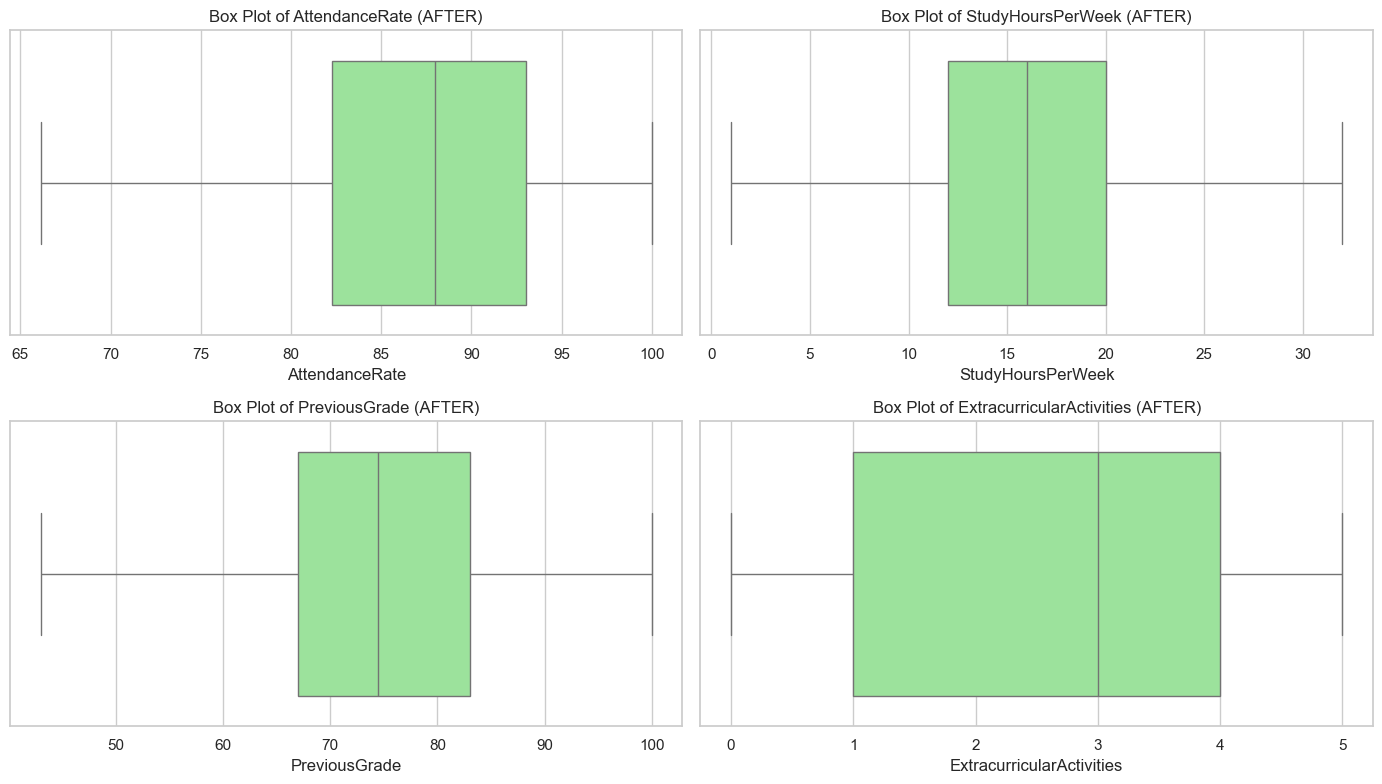

In [8]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Box Plot of {col} (AFTER)')
plt.tight_layout()
plt.show()

In [9]:
print("Number of outliers AFTER handling:")
for col in numerical_features:
    print(f"{col}: {count_outliers(df[col])}")

Number of outliers AFTER handling:
AttendanceRate: 0
StudyHoursPerWeek: 0
PreviousGrade: 0
ExtracurricularActivities: 0


## 6. Exploratory Data Analysis (EDA)
Finally, we visualize the core relationships between features and our target variable, `FinalGrade`.

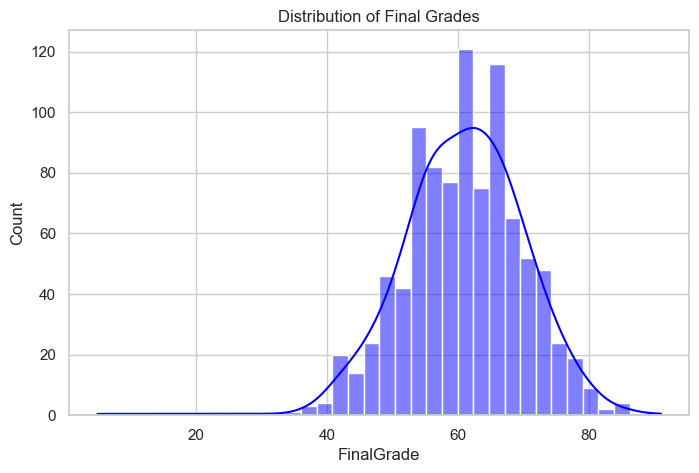

In [10]:
# Drop identifiers if they still exist
if 'StudentID' in df.columns:
    df = df.drop(columns=['StudentID'])
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

plt.figure(figsize=(8, 5))
sns.histplot(df['FinalGrade'], kde=True, color='blue')
plt.title('Distribution of Final Grades')
plt.show()

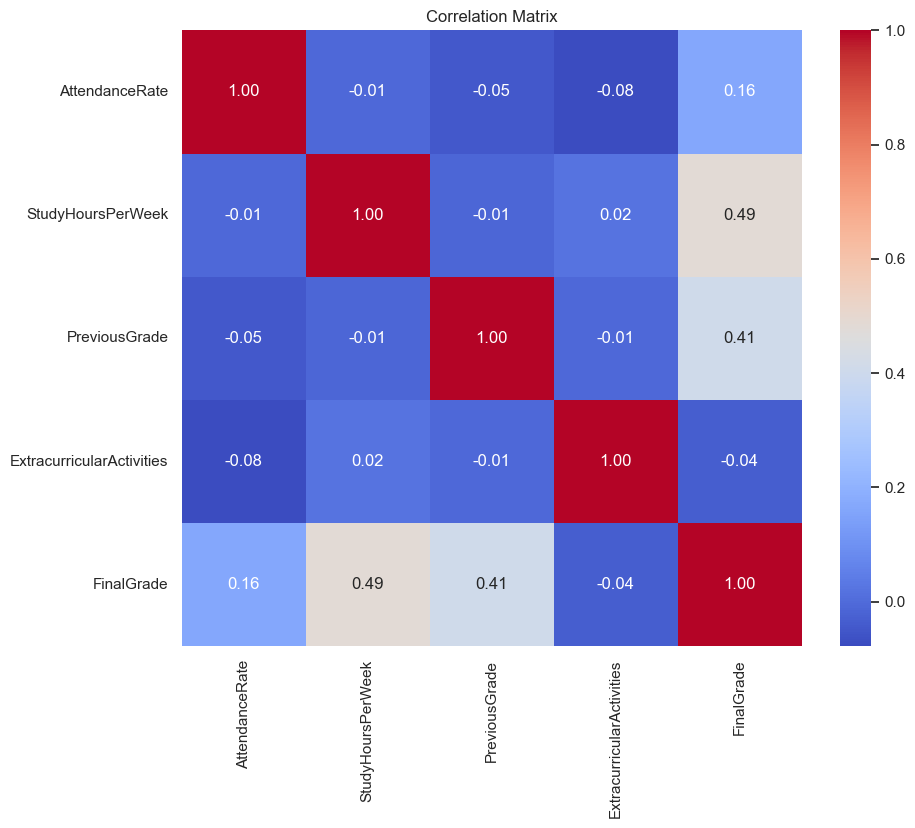

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

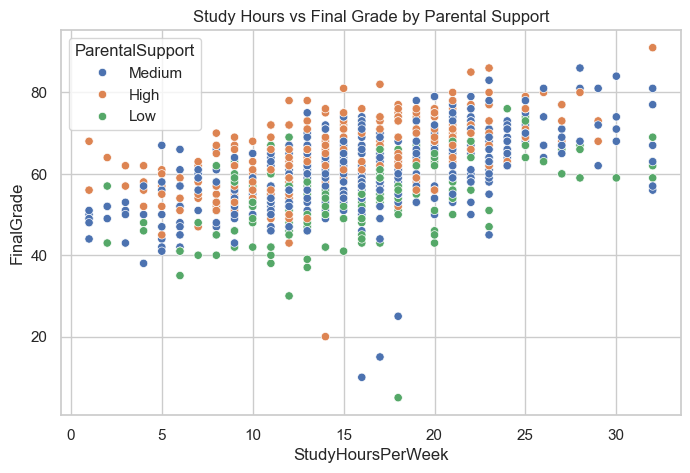

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='StudyHoursPerWeek', y='FinalGrade', hue='ParentalSupport', data=df)
plt.title('Study Hours vs Final Grade by Parental Support')
plt.show()

## 7. Model Training & Comparison
To understand which features are the strongest predictors of a student's final grade, we will train and compare three machine learning models: **Random Forest Regressor**, **XGBoost Regressor**, and **Linear Regression**. We will evaluate them using RMSE, MAE, R², and Adjusted R², and then select the best-performing model to extract its Feature Importances or Coefficients. We drop `Gender` to match the project's production pipeline and use `OneHotEncoder(drop='first')` to avoid multicollinearity.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Prepare features and target
#    Drop Gender to match the project's production pipeline (train_and_eda.py + web app)
X = df.drop(columns=['FinalGrade', 'Gender'])
y = df['FinalGrade']

categorical_cols = ['ParentalSupport']
numerical_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities']

# 2. Create preprocessing pipeline
#    drop='first' avoids multicollinearity by dropping the first category (reference encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize Pipelines with StandardScaler after preprocessor, matching the production pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('scaler', StandardScaler()),
                              ('model', RandomForestRegressor(n_estimators=100, random_state=42))])

xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('scaler', StandardScaler()),
                               ('model', XGBRegressor(n_estimators=100, random_state=42))])

lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('scaler', StandardScaler()),
                              ('model', LinearRegression())])

# 5. Train Models
print("Training models...")
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
lr_pipeline.fit(X_train, y_train)

# 6. Evaluate Models
results = []
models = {
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "Linear Regression": lr_pipeline
}

fitted_preprocessor = lr_pipeline.named_steps['preprocessor']
p = fitted_preprocessor.transform(X_test).shape[1]
n = X_test.shape[0]

for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Adjusted R2": adj_r2
    })

results_df = pd.DataFrame(results)
print("\nModel Comparison Table:")
print(results_df.to_string(index=False))

best_row = results_df.loc[results_df['R2'].idxmax()]
best_model_name = best_row['Model']
best_pipeline = models[best_model_name]
print(f"\nBest Model Selected: {best_model_name} (R2: {best_row['R2']:.4f})")


Training models...

Model Comparison Table:
            Model     RMSE      MAE       R2  Adjusted R2
    Random Forest 5.838743 4.458228 0.592601     0.579243
          XGBoost 6.519978 4.938601 0.491988     0.475332
Linear Regression 5.198772 3.934360 0.677014     0.666425

Best Model Selected: Linear Regression (R2: 0.6770)


Feature Importance / Coefficient Ranking (Linear Regression):
                  StudyHoursPerWeek: 4.8761
                ParentalSupport_Low: 4.2222
                      PreviousGrade: 3.9170
             ParentalSupport_Medium: 2.4471
                     AttendanceRate: 1.6975
          ExtracurricularActivities: 0.0978


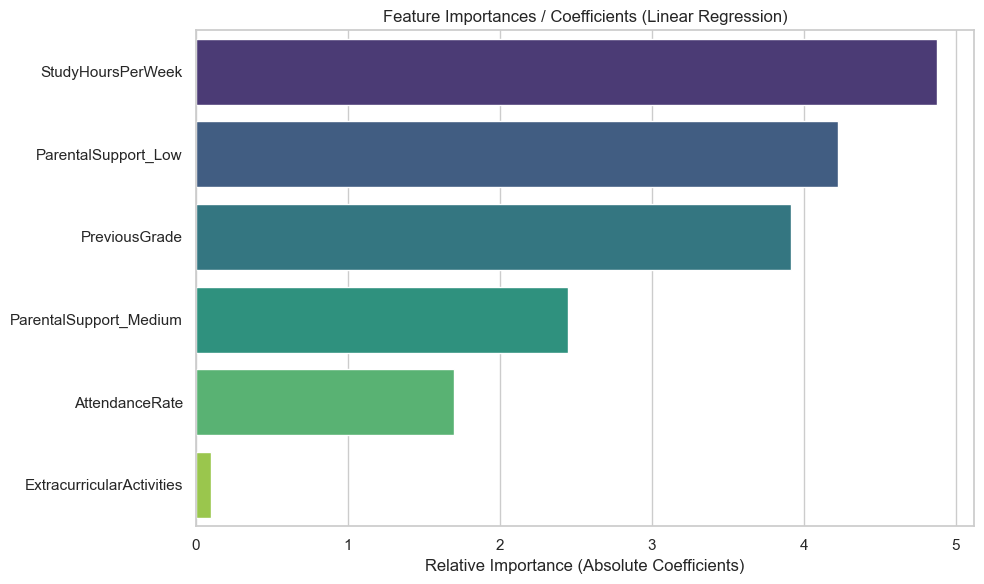

In [14]:
# 7. Extract Feature Importances / Coefficients
best_model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_features = numerical_cols + list(cat_features)

# Extract importances or coefficients based on the model type
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    importance_type = "Relative Importance"
else:
    # Use absolute value of coefficients for linear models
    importances = np.abs(best_model.coef_)
    importance_type = "Relative Importance (Absolute Coefficients)"

indices = np.argsort(importances)[::-1]

print(f"Feature Importance / Coefficient Ranking ({best_model_name}):")
print("=" * 60)
for i in indices:
    print(f"{all_features[i]:>35s}: {importances[i]:.4f}")

# 8. Visualize Feature Importances / Coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(all_features)[indices], palette="viridis", hue=np.array(all_features)[indices], legend=False)
plt.title(f'Feature Importances / Coefficients ({best_model_name})')
plt.xlabel(importance_type)
plt.tight_layout()
plt.show()
